In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Callable, Tuple

df = pd.read_csv("./ablate_results/all_statistics.csv")


do_models = [
    "Qwen/Qwen3-4B",
    "meta-llama/Llama-3.2-3B-Instruct",
    "Qwen/Qwen3-8B",
    "meta-llama/Llama-3.1-8B-Instruct"
]
models_safenames = [m.replace("/", "__") for m in do_models]
model_ablations = ["cadgn", "adgn", "gcn", "gat", "dec"]





In [2]:
# Coerce values
if df["reject_h0"].dtype == object:
    df["reject_h0"] = df["reject_h0"].str.strip().str.upper() == "TRUE"

df["direction_int"] = pd.to_numeric(df["direction_int"], errors="coerce")


# Extract necessary details
df["a_abl"] = df["variant_a"].str.split("_").str[0]
df["a_mmd"] = df["variant_a"].str.split("_").str[1].str.split("-").str[1].astype(int)
df["a_mdl"] = df["variant_a"].str.split("_").str[2]


df["b_abl"] = df["variant_b"].str.split("_").str[0]
df["b_mmd"] = df["variant_b"].str.split("_").str[1].str.split("-").str[1].astype(int)
df["b_mdl"] = df["variant_b"].str.split("_").str[2]
print(df[["variant_a", "a_abl", "a_mmd", "a_mdl"]].head())
print(df[["variant_b", "b_abl", "b_mmd", "b_mdl"]].head())

                   variant_a  a_abl  a_mmd          a_mdl
0  cadgn_mmd-0_Qwen/Qwen3-4B  cadgn      0  Qwen/Qwen3-4B
1  cadgn_mmd-0_Qwen/Qwen3-4B  cadgn      0  Qwen/Qwen3-4B
2  cadgn_mmd-0_Qwen/Qwen3-4B  cadgn      0  Qwen/Qwen3-4B
3  cadgn_mmd-0_Qwen/Qwen3-4B  cadgn      0  Qwen/Qwen3-4B
4  cadgn_mmd-0_Qwen/Qwen3-4B  cadgn      0  Qwen/Qwen3-4B
                                      variant_b  b_abl  b_mmd  \
0  cadgn_mmd-0_meta-llama/Llama-3.2-3B-Instruct  cadgn      0   
1                     cadgn_mmd-0_Qwen/Qwen3-8B  cadgn      0   
2  cadgn_mmd-0_meta-llama/Llama-3.1-8B-Instruct  cadgn      0   
3                      adgn_mmd-0_Qwen/Qwen3-4B   adgn      0   
4   adgn_mmd-0_meta-llama/Llama-3.2-3B-Instruct   adgn      0   

                              b_mdl  
0  meta-llama/Llama-3.2-3B-Instruct  
1                     Qwen/Qwen3-8B  
2  meta-llama/Llama-3.1-8B-Instruct  
3                     Qwen/Qwen3-4B  
4  meta-llama/Llama-3.2-3B-Instruct  


================== YN_CORRECT ==================


First Set!




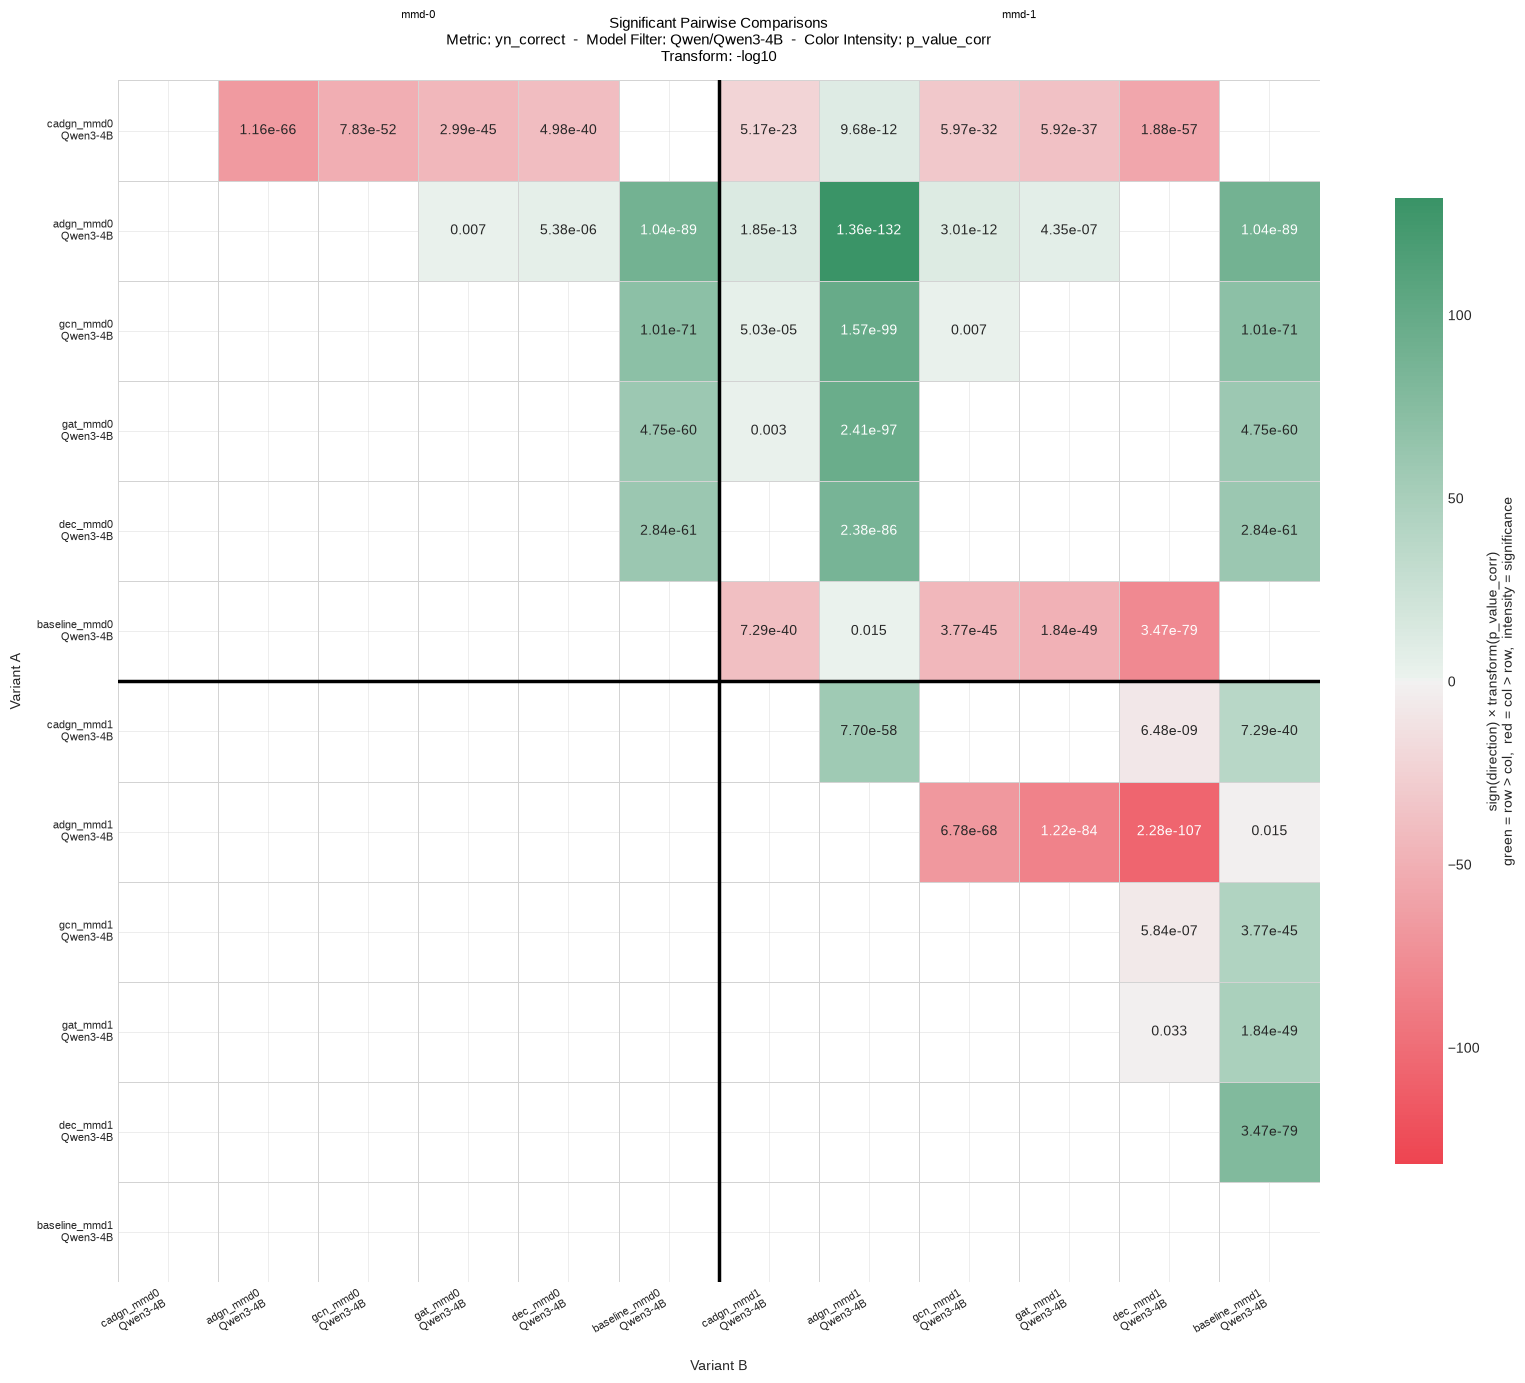

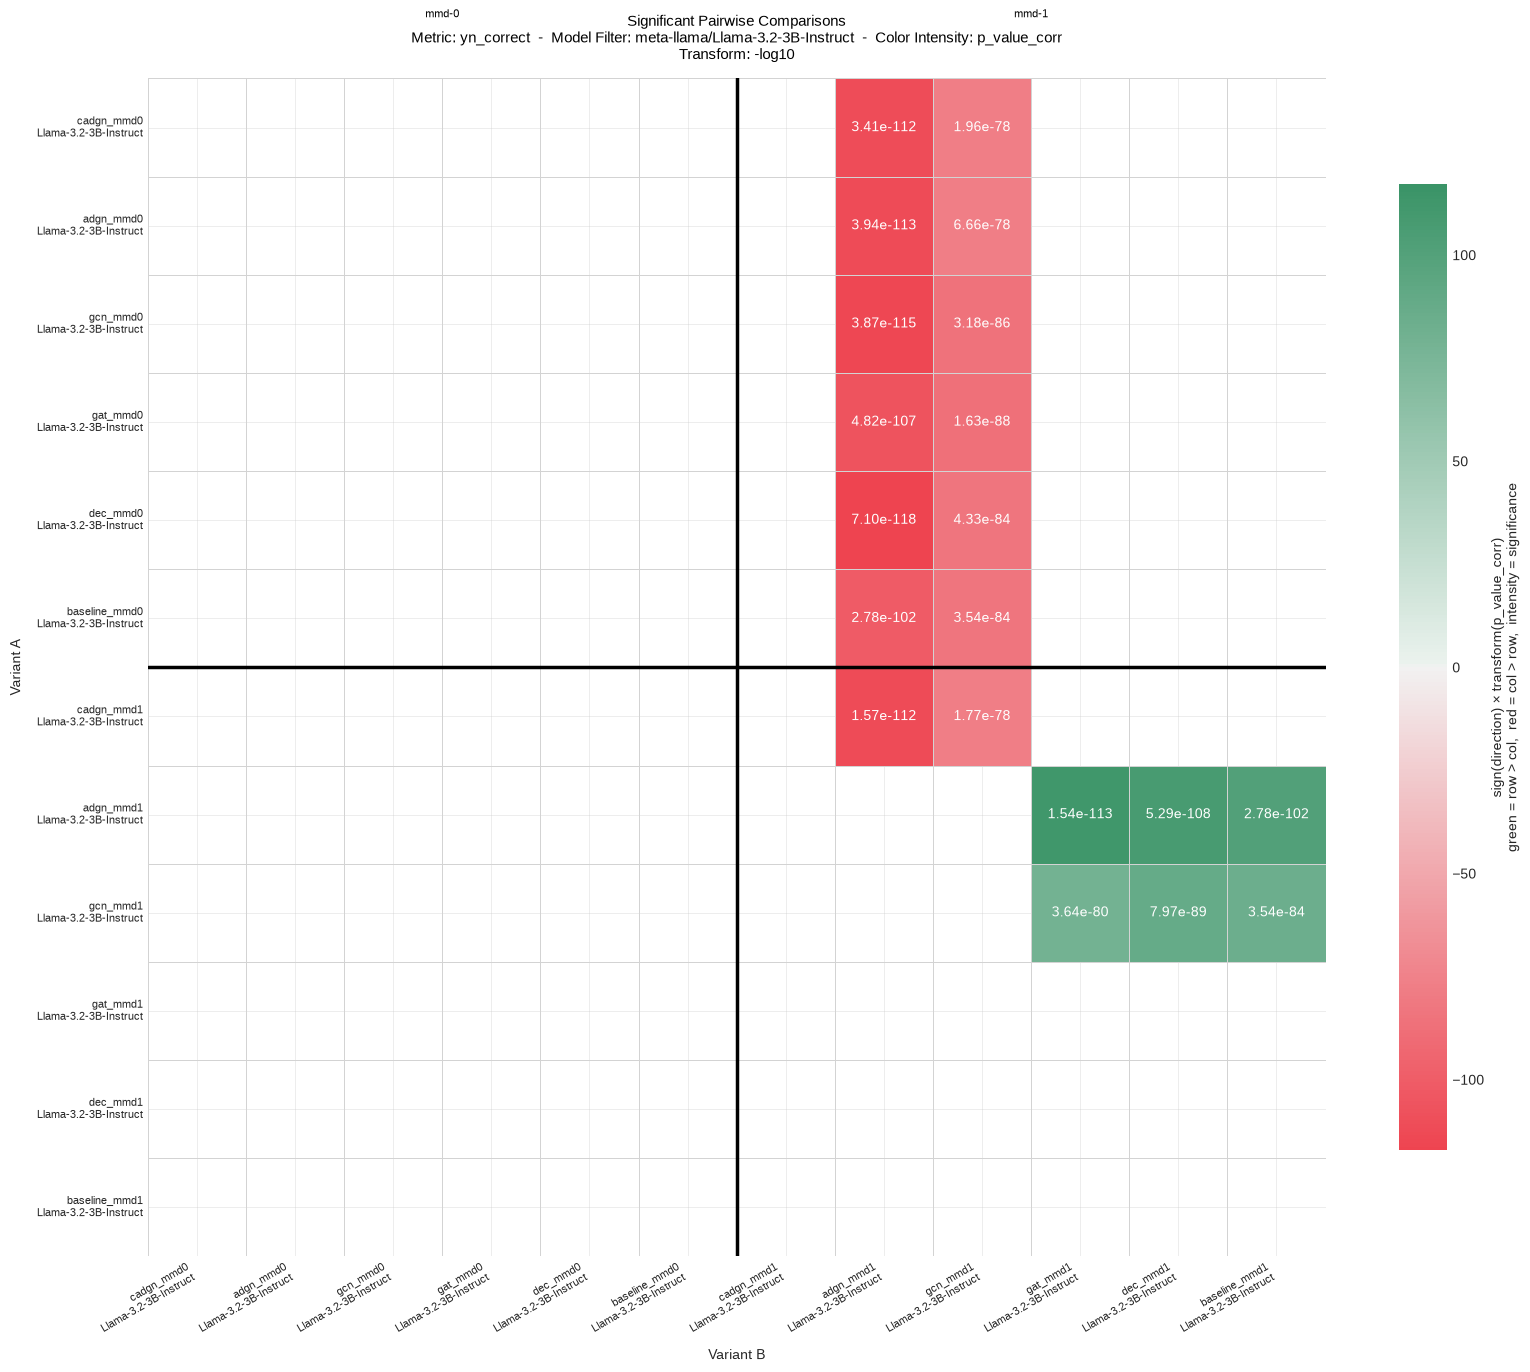

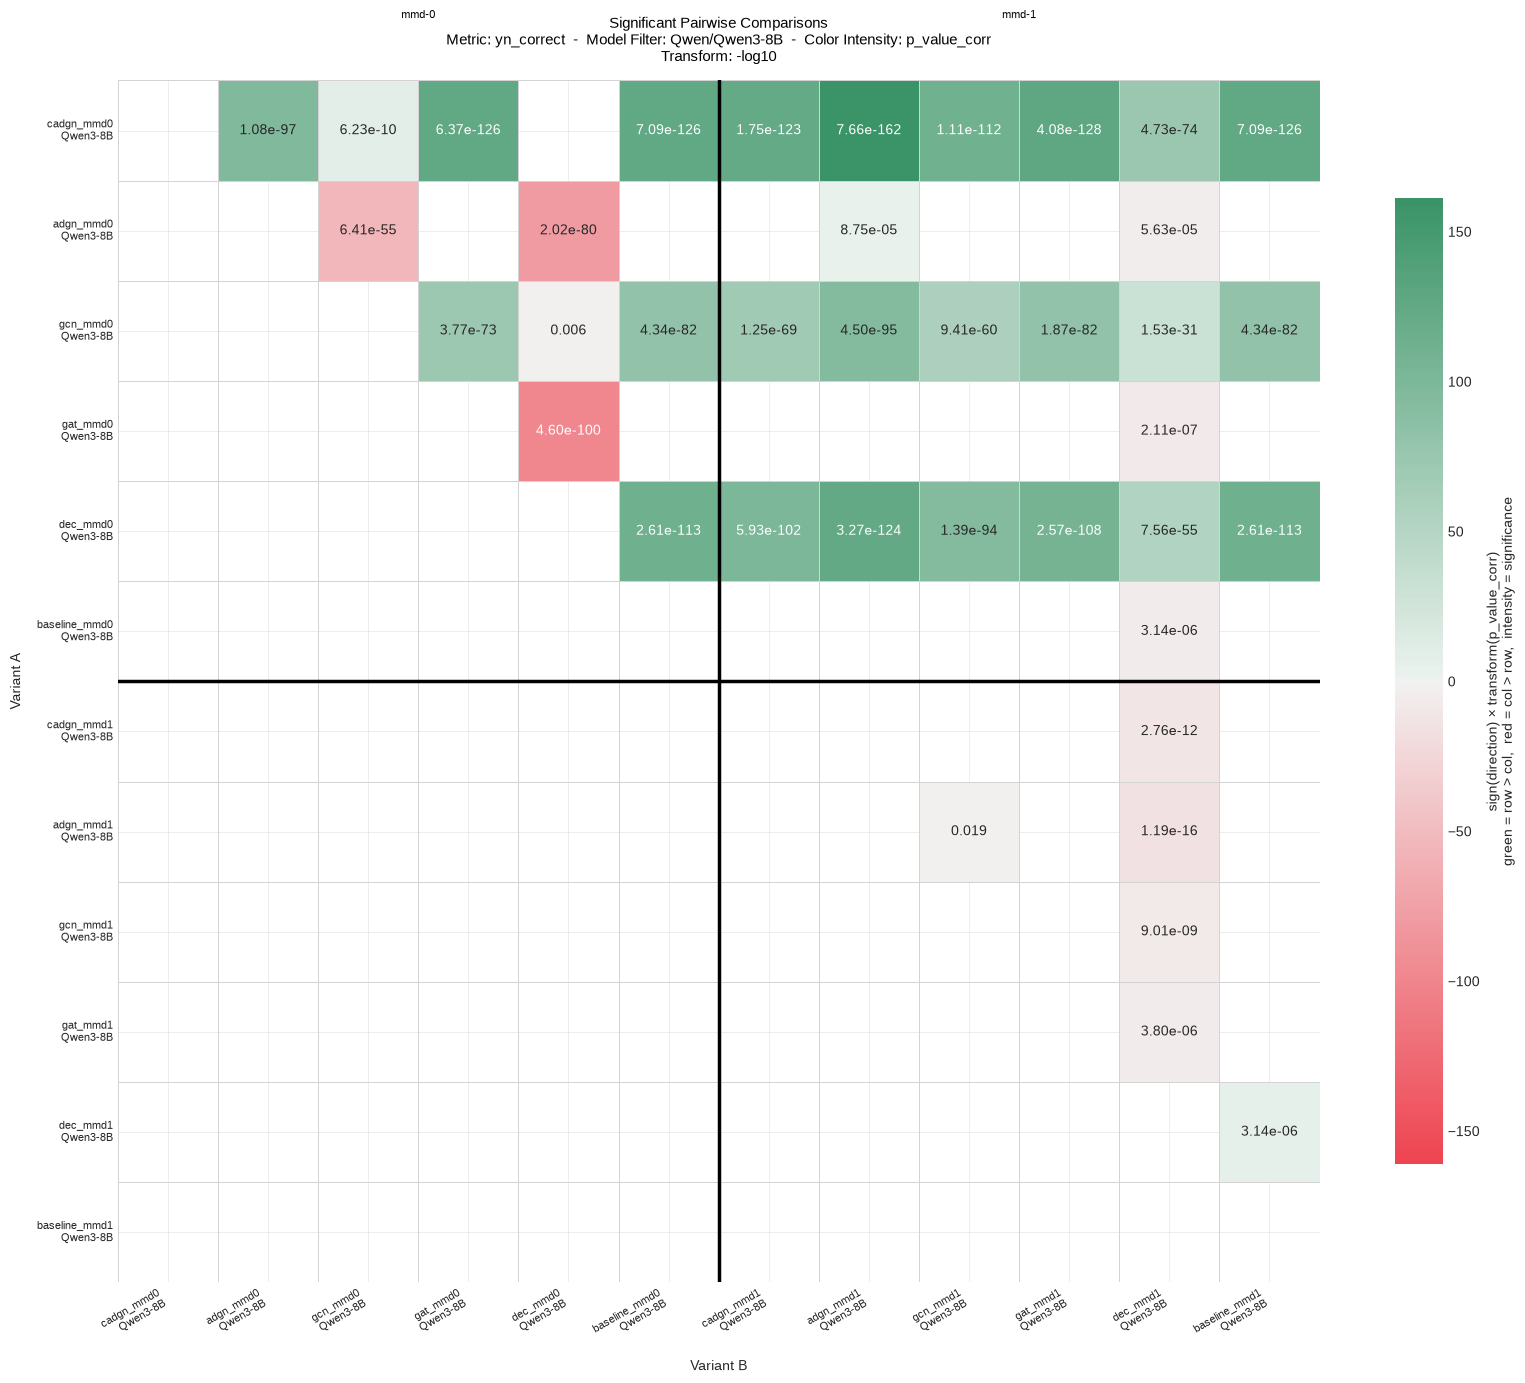

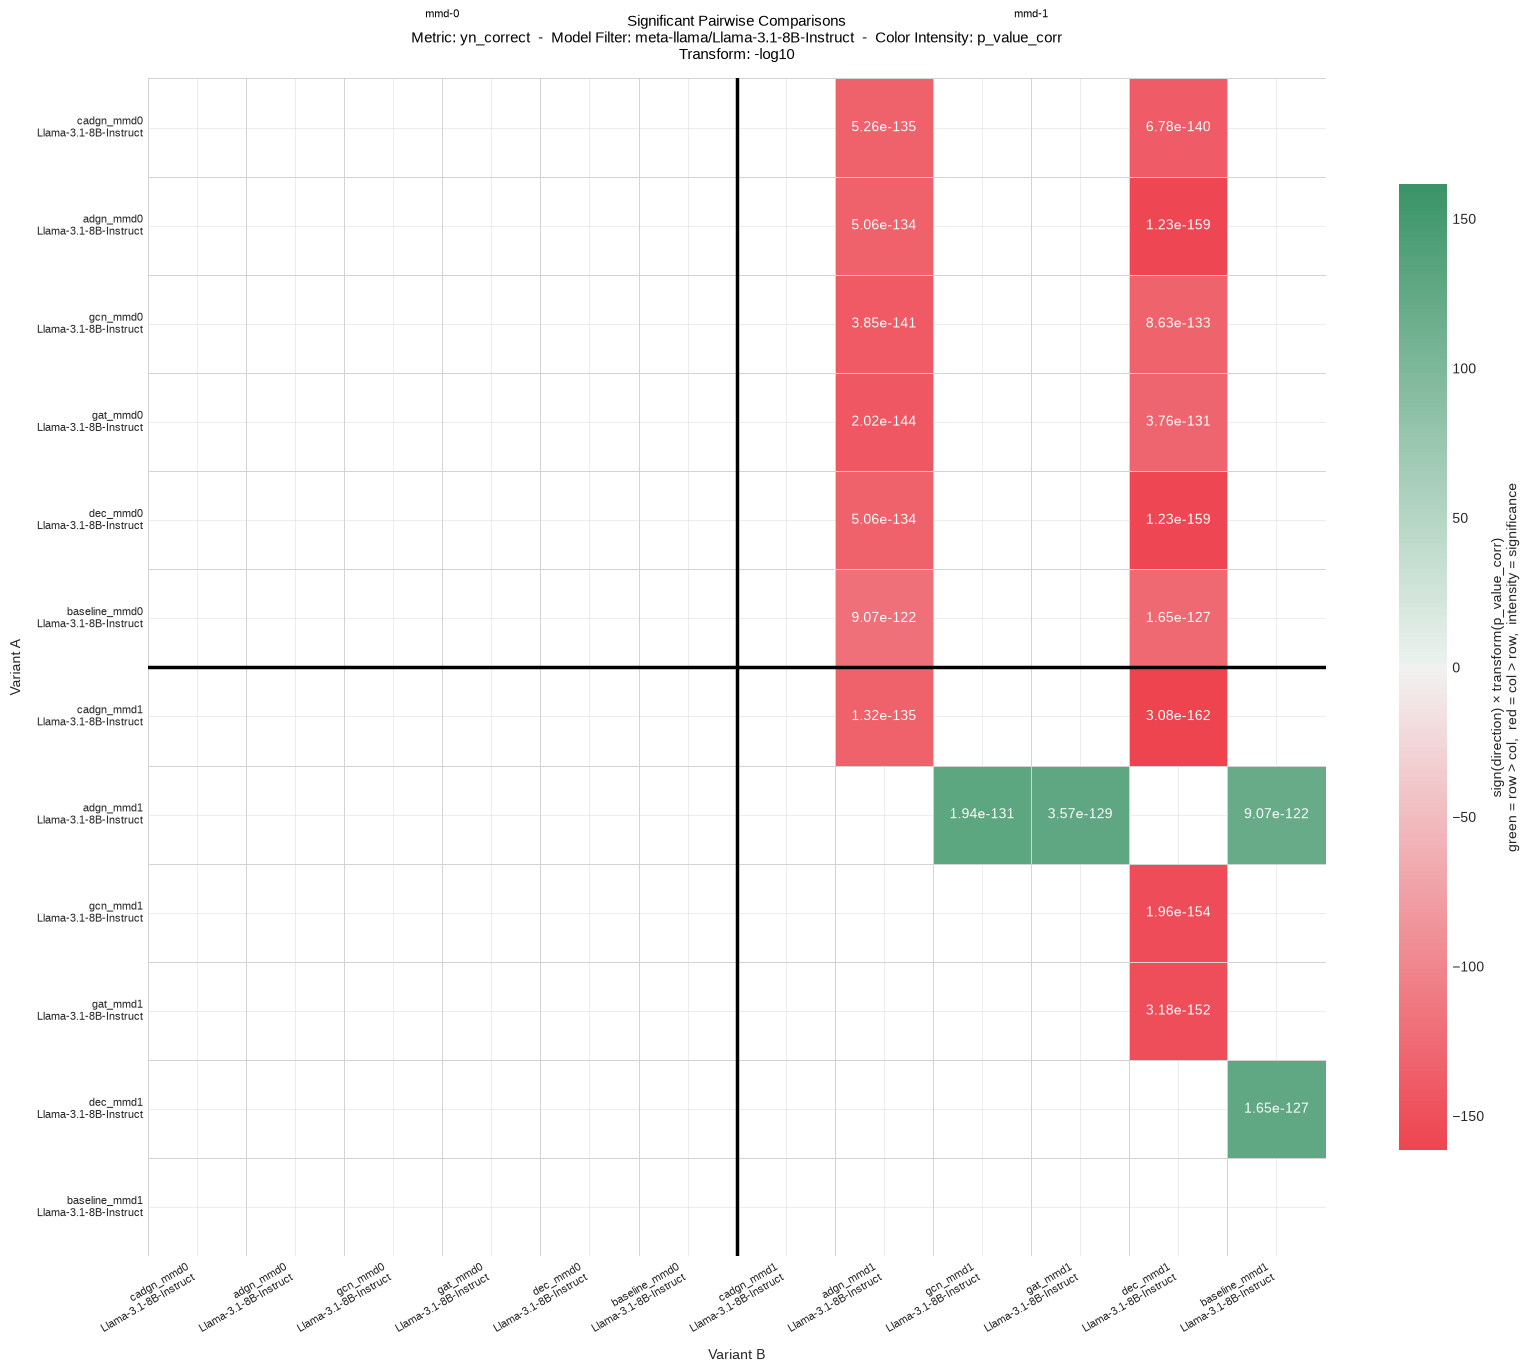



Second set!


cadgn



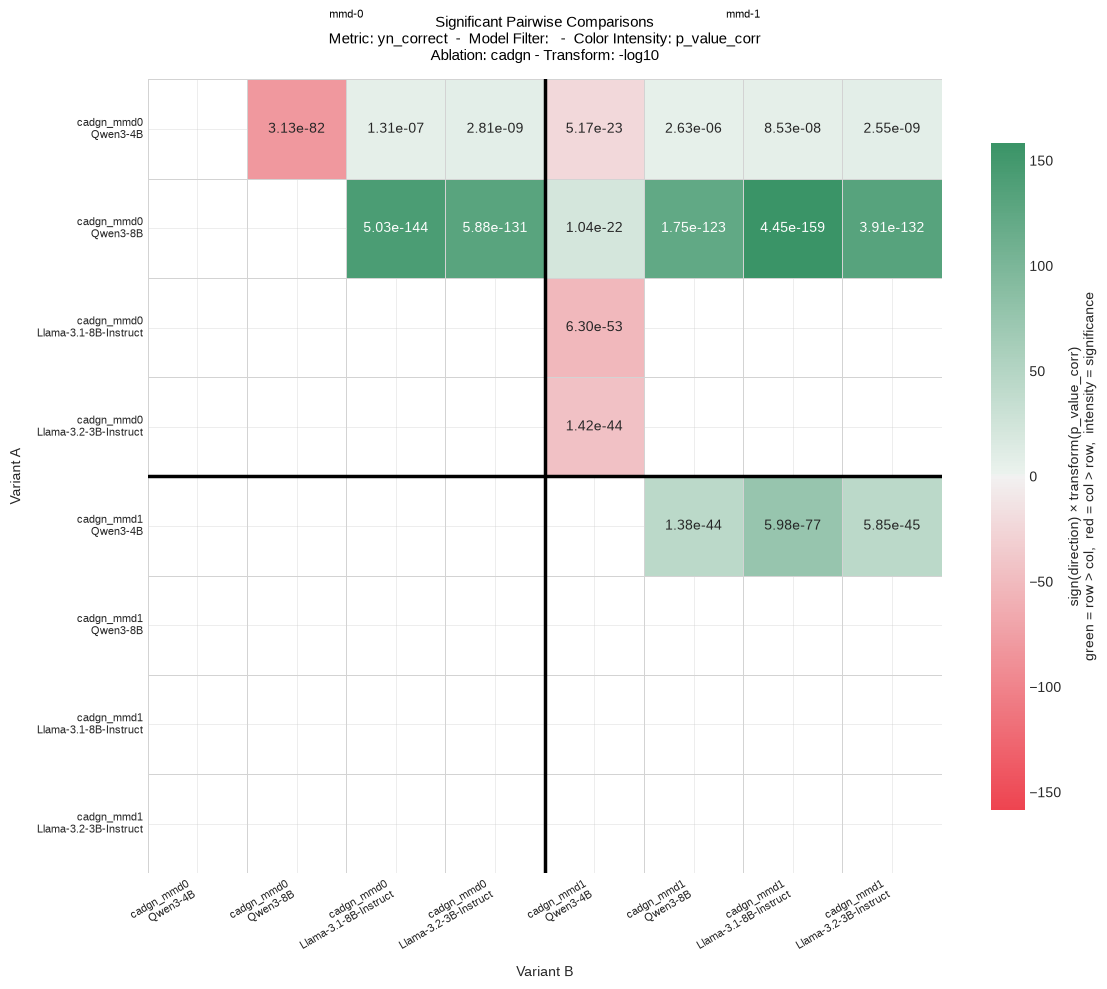

adgn



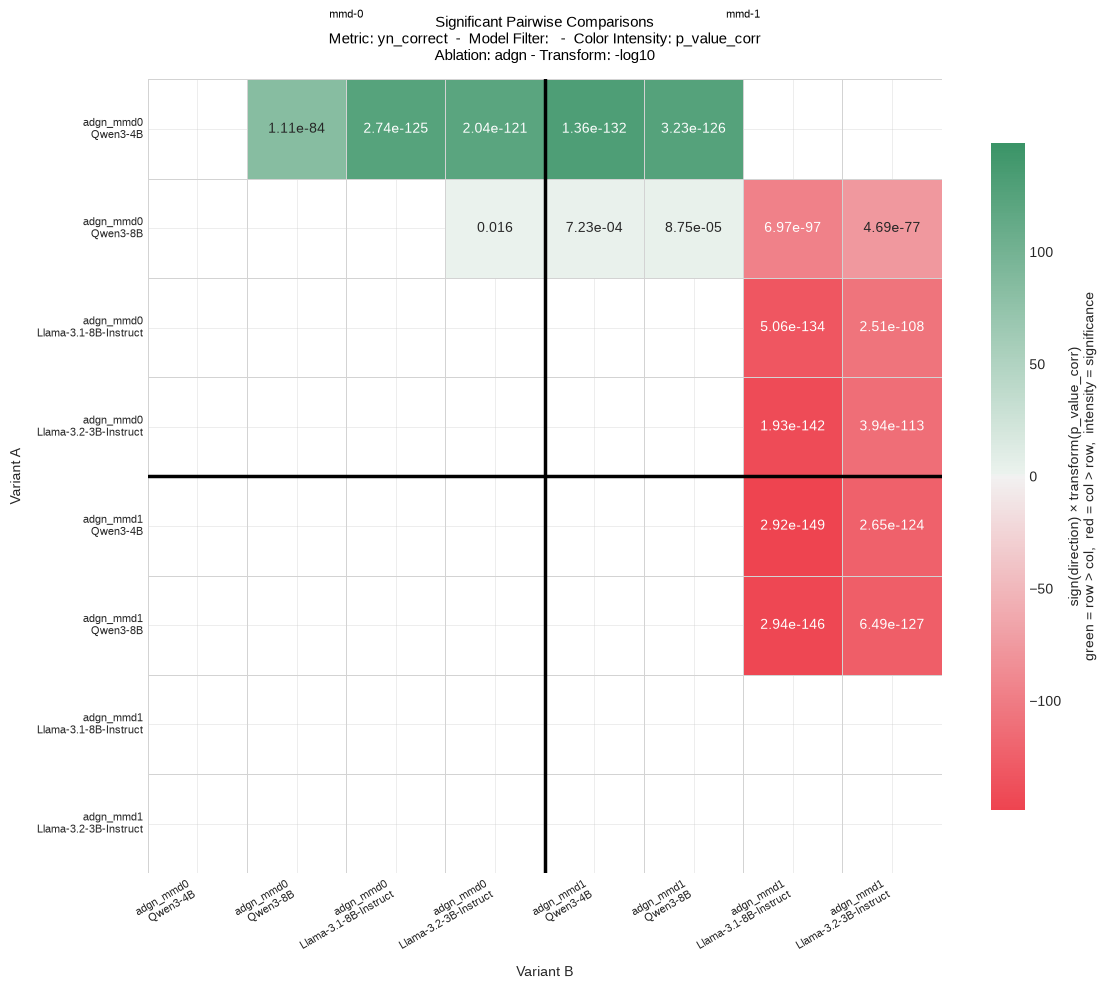

gcn



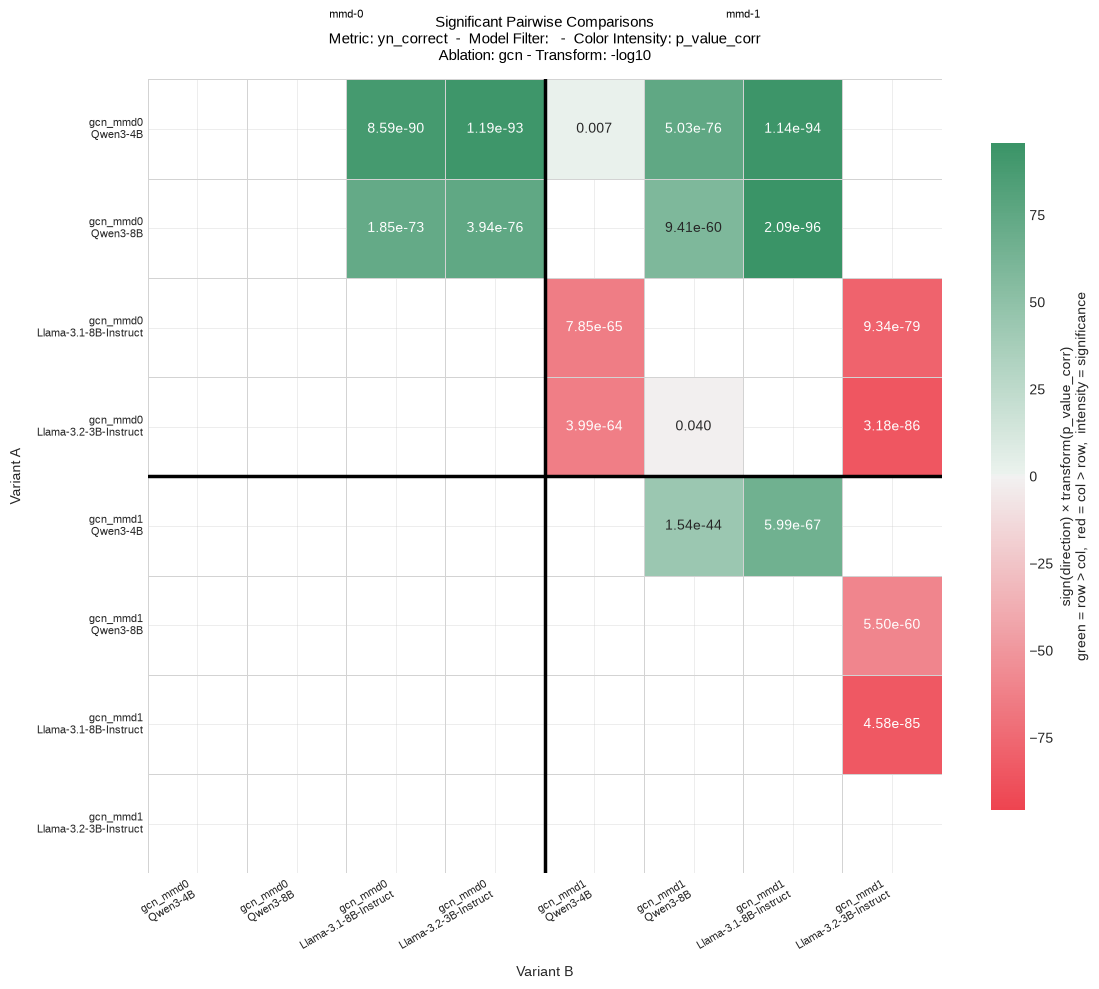

gat



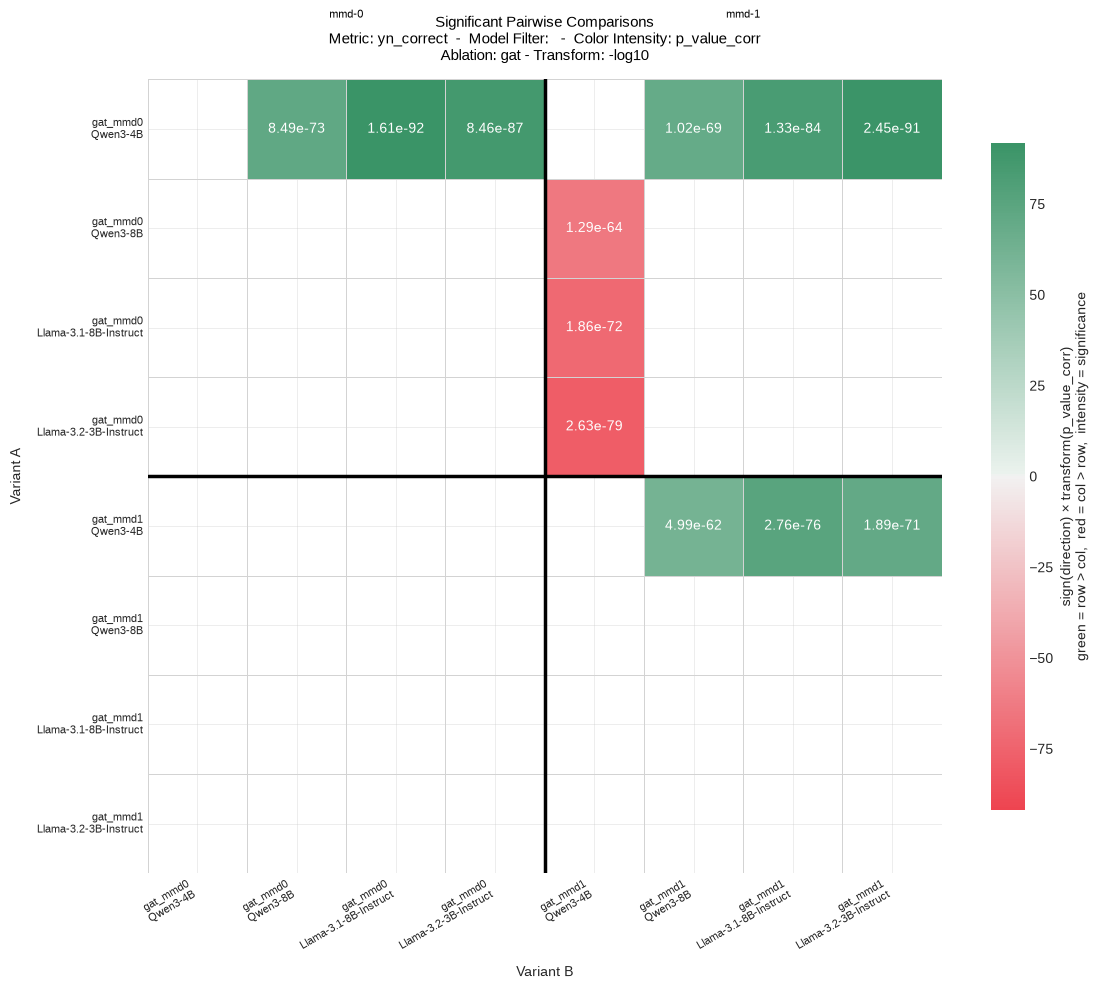

dec



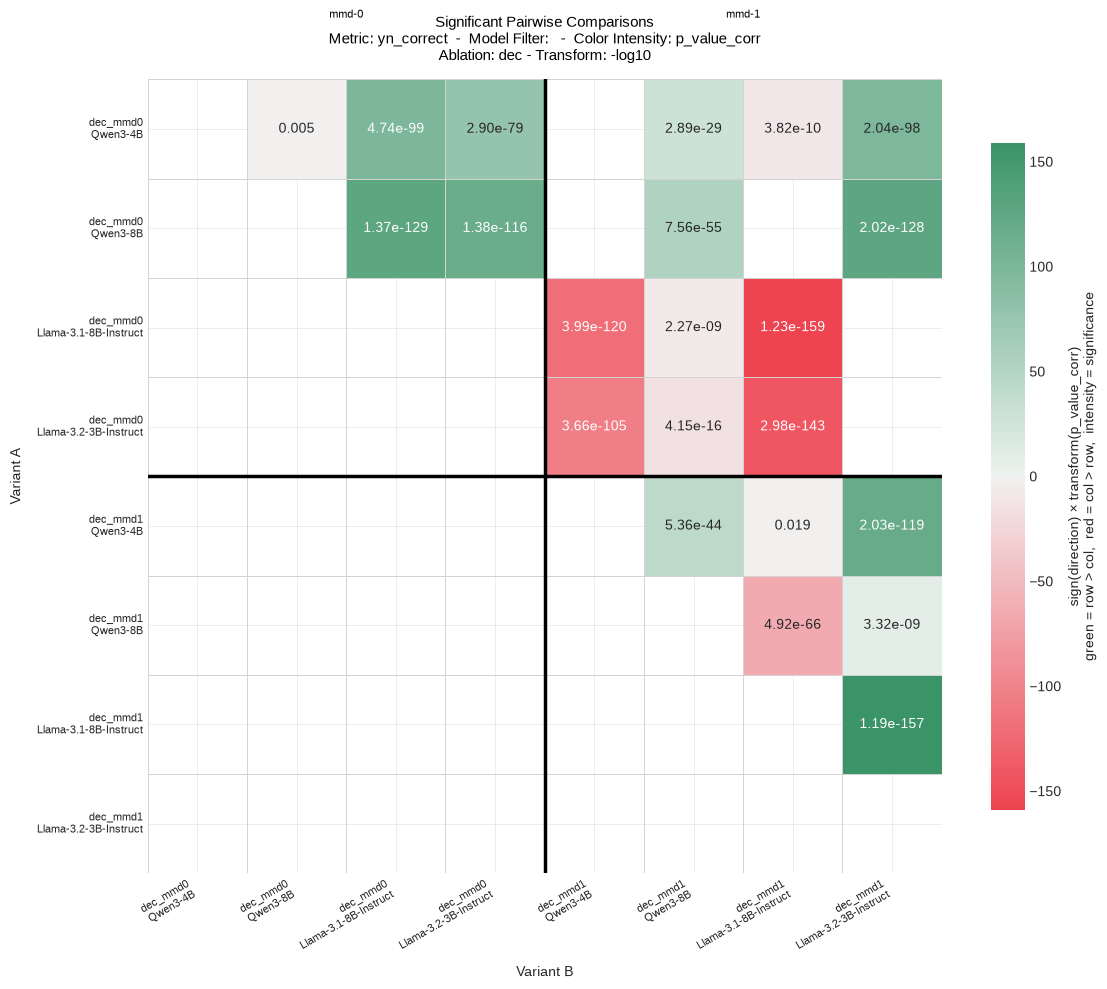

baseline

[] No significant comparisons for 'yn_correct' with these conditions.



Third Set




In [3]:
from typing import Optional
from pandas import DataFrame, Series
LIGHT_MODE = True
plt.style.use("seaborn-v0_8-whitegrid")

ABL_ORDER = ["cadgn", "adgn", "gcn", "gat", "dec", "baseline"]
cmap = sns.diverging_palette(10, 145, s=80, l=55, as_cmap=True)  # red to green

def sort_key(variant: str) -> tuple:
    parts = variant.split("_")
    abl = parts[0]
    mmd_n = int(parts[1].split("-")[1])
    mdl = parts[2]
    return (mmd_n, ABL_ORDER.index(abl) if abl in ABL_ORDER else 99, mdl)

def short_label(variant: str) -> str:
    parts = variant.split("_")
    abl = parts[0]
    mmd_n = parts[1].split("-")[1]
    mdl_short = parts[2].split("/")[-1]  # drop org prefix (Qwen/, meta-llama/)
    return f"{abl}_mmd{mmd_n}\n{mdl_short}"

def _fmt_value(v: float) -> str:
    """Sensible annotation format for both p-values and chi-sq statistics."""
    if v < 0.001:
        return f"{v:.2e}"
    elif v < 1:
        return f"{v:.3f}"
    else:
        return f"{v:.2f}"


def make_graph_for_model(
        df,
        mdl,
        conds: Callable[[DataFrame, str], Series],
        metric: str = "yn_correct",
        intensity_col: str = "p_value_corr",
        intensity_transform: Callable[[float], float] | None = None,
        title_add: str = ""
) -> Optional[Tuple[plt.Figure, plt.Axes]]:
    """

    :param df:
    :param mdl:
    :param conds:
    :param metric:
    :param intensity_col: Used to control what column is used to color the graph.
    :param intensity_transform:
    :param title_add: String to add to Title to differentiate otherwise than already provided.
    :return:

    `intensity_col` examples:
        - "p_value_corr" - pair with default -log10 transform for McNemar & Stuart-Maxwell tests)
        - "statistic" - pass `intensity_transform=lambda x: x (raw chi-sq)`
        - "statistic" - pass `intensity_transform=lambda x: 1-x (ASO epsilon)`
    """
    if intensity_transform is None:
        # -log10(p): small p = large positive number => strong colour
        intensity_transform = lambda x: -np.log10(max(float(x), 1e-300))

    sig = df[
    (df["metric"] == metric)
    & (df["reject_h0"])
    & conds(df, mdl)
    ].copy()

    if sig.empty:
        print(f"[{mdl}] No significant comparisons for '{metric}' with these conditions.\n")
        return None


    all_variants = sorted(
    pd.unique(
        sig[["variant_a", "variant_b"]].values.ravel()),
        key=sort_key,
    )
    label_map = {v: short_label(v) for v in all_variants}
    labels = [label_map[v] for v in all_variants]
    n = len(labels)

    # Antisymmetric direction matrix
    # Cell (A, B) = +1 means A > B; mirrored cell (B, A) = -1 by definition
    matrix = pd.DataFrame(np.nan, index=labels, columns=labels)
    # String annotations — empty by default, filled only in upper triangle
    annot_matrix = pd.DataFrame("", index=labels, columns=labels)

    for _, row in sig.iterrows():
        la = label_map[row["variant_a"]]
        lb = label_map[row["variant_b"]]
        d = int(row["direction_int"])
        raw_val = float(row[intensity_col])
        signed = d * intensity_transform(raw_val)

        matrix.loc[la, lb] = signed
        matrix.loc[lb, la] = -signed

        # Annotation goes in whichever of (la,lb) or (lb,la) is upper triangle
        i, j = labels.index(la), labels.index(lb)
        if i < j:
            annot_matrix.loc[la, lb] = _fmt_value(raw_val)
        else:
            annot_matrix.loc[lb, la] = _fmt_value(raw_val)


    tril_mask = np.tril(np.ones( (n,n), dtype=bool), k=-1)
    mask = matrix.isna() | tril_mask

    # Plot
    abs_max = np.nanmax(np.abs(matrix.values))
    cell_size = 1.2
    fig, ax = plt.subplots(figsize=(n * cell_size + 2, n * cell_size + 2))
    if LIGHT_MODE:
        fig.patch.set_facecolor("white")
        ax.set_facecolor("white")

    sns.heatmap(
        matrix,
        center=0,
        vmin=-abs_max,
        vmax=abs_max,
        cmap=cmap,
        ax=ax,
        annot=annot_matrix,
        fmt="",  # when annot is a dataframe of strings, this must be ""
        square=True,
        linewidths=0.5,
        linecolor="lightgrey",
        mask=mask,
        cbar_kws={
            "label": (
                f"sign(direction) × transform({intensity_col})\n"
                f"green = row > col,  red = col > row,  "
                f"intensity = significance"
            ),
            "shrink": 0.6,
        },
    )

    ## MMD-block divider
    n_mmd0 = sum(
        1 for v in all_variants
        if int(v.split("_")[1].split("-")[1]) == 0
    )
    if 0 < n_mmd0 < n:
        ax.axhline(n_mmd0, color="black", linewidth=2.5, zorder=5)
        ax.axvline(n_mmd0, color="black", linewidth=2.5, zorder=5)
        # Optional: block labels in the margin
        ax.text(
            n_mmd0 / 2, -0.6, "mmd-0", ha="center", va="bottom",
            fontsize=8, color="white" if not LIGHT_MODE else "black", transform=ax.transData,
        )
        ax.text(
            n_mmd0 + (n - n_mmd0) / 2, -0.6, "mmd-1", ha="center", va="bottom",
            fontsize=8, color="white" if not LIGHT_MODE else "black", transform=ax.transData,
        )

    ax.set_title(
        f"Significant Pairwise Comparisons\n"
        f"Metric: {metric}  -  Model Filter: {mdl}  -  Color Intensity: {intensity_col}\n" + title_add,
        fontsize=11,
        pad=14,
        color= "white" if not LIGHT_MODE else "black"
    )

    ax.set_xlabel("Variant B", labelpad=10)
    ax.set_ylabel("Variant A", labelpad=10)
    plt.xticks(rotation=30, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()

    return fig, ax

from pathlib import Path
outputdir = Path("./ablate_results/figures")
outputdir.mkdir(exist_ok=True, parents=True)
abl_per_mdl_dir = outputdir / "abl_per_mdl"
abl_per_mdl_dir.mkdir(exist_ok=True, parents=True)
comp_dir = outputdir / "comp"
comp_dir.mkdir(exist_ok=True, parents=True)

print("================== YN_CORRECT ==================")
print("\n\nFirst Set!\n\n")
for mdl in do_models:
    within = df[(df["a_mdl"] == mdl) & (df["b_mdl"] == mdl)]
    #print(f"[{mdl}] a_abl: {within['a_abl'].unique()}, b_abl: {within['b_abl'].unique()}")

    result = make_graph_for_model(
        df,
        mdl,
        lambda d, m: (d["a_mdl"] == m) & (d["b_mdl"] == m),
        title_add="Transform: -log10"
    )
    if result is not None:
        fig: plt.Figure = result[0]
        plt.show(fig)
        safename = mdl.replace("/", "__")
        fig.savefig(abl_per_mdl_dir / f'{safename}_ablations_significant.png', dpi=300, bbox_inches="tight")
        plt.close(fig)

print("\n\nSecond set!\n\n")
#for mdl in do_models:
for abl in ABL_ORDER:
    print(f"{abl}\n")
    conds = lambda d, _, _abl=abl: (d["a_abl"] == _abl) & (d["b_abl"] == _abl)
    result = make_graph_for_model(
        df,
        "",
        conds,
        title_add = "Ablation: " + abl + " - Transform: -log10",
    )

    if result is not None:
        fig: plt.Figure = result[0]
        plt.show(fig)
        fig.savefig(comp_dir / f'{abl}_acrs_mdls_ablations_significant.png', dpi=300, bbox_inches="tight")
        plt.close(fig)

print("\n\nThird Set\n\n")











